In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [21]:
def generate_pulse_trains(p1, p2, length):
    rand1 = np.random.rand(length)
    rand2 = np.random.rand(length)
    return (rand1 < p1).astype(int), (rand2 < p2).astype(int)


def count_coincidences(pt1, pt2):
    return np.sum(pt1 & pt2)

def count_ones(pt):
    return np.sum(pt)

if __name__ == "__main__":
    p1 = 0.5
    p2 = 0.5

    lengths = np.arange(1, 500, 1)
    trials = 100000 # increase for smoother curves

    means1 = []
    stds1 = []
    for length in tqdm(lengths, desc="Lengths"):
        results = []

        for _ in tqdm(range(trials), desc=f"Length={length}", leave=False):
            pt1, pt2 = generate_pulse_trains(p1, p2, length)

            # coincidence
            probability = count_coincidences(pt1, pt2) / length
            results.append(probability)

        means1.append(np.mean(results))
        stds1.append(np.std(results))



    means2 = []
    stds2 = []
    for length in tqdm(lengths, desc="Lengths"):
        results = []

        for _ in tqdm(range(trials), desc=f"Length={length}", leave=False):
            pt1, pt2 = generate_pulse_trains(p1, p2, length)
            c1 = count_ones(pt1)
            c2 = count_ones(pt2)
            # coincidence
            probability = (c1/length) * (c2/length)  # count_coincidences(pt1, pt2) / length
            results.append(probability)

        means2.append(np.mean(results))
        stds2.append(np.std(results))


Lengths: 100%|██████████| 499/499 [06:20<00:00,  1.31it/s]


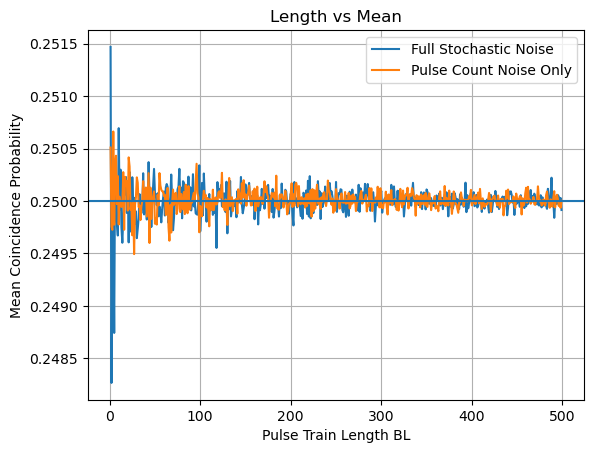

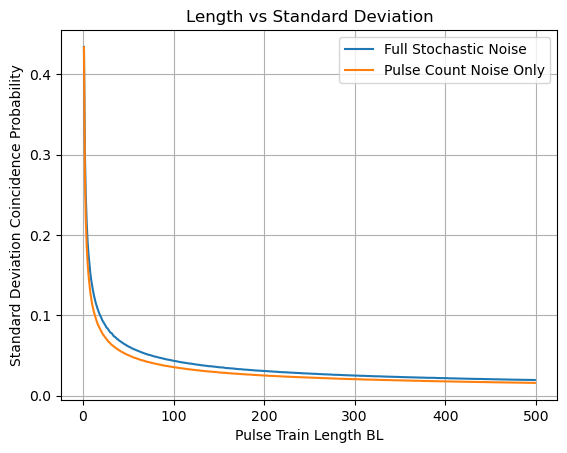

<Figure size 640x480 with 0 Axes>

In [22]:

# ---- Plot Mean ----
plt.figure()
plt.plot(lengths, means1, label="Full Stochastic Noise")
plt.plot(lengths, means2, label="Pulse Count Noise Only")
plt.axhline(p1 * p2)
plt.xlabel("Pulse Train Length BL")
plt.ylabel("Mean Coincidence Probability")
plt.title("Length vs Mean")
plt.grid()
plt.legend()


# ---- Plot Std ----
plt.figure()
plt.plot(lengths, stds1, label="Full Stochastic Noise")
plt.plot(lengths, stds2, label="Pulse Count Noise Only")
plt.xlabel("Pulse Train Length BL")
plt.ylabel("Standard Deviation Coincidence Probability")
plt.title("Length vs Standard Deviation")
plt.grid()
plt.legend()
plt.figure()
plt.show()

In [ ]:

def generate_fixed_shuffled(p1, p2, length):
    k1 = int(round(p1 * length))
    k2 = int(round(p2 * length))

    # create arrays with fixed number of 1s
    arr1 = np.array([1]*k1 + [0]*(length - k1))
    arr2 = np.array([1]*k2 + [0]*(length - k2))

    # shuffle in-place
    np.random.shuffle(arr1)
    np.random.shuffle(arr2)

    return arr1, arr2


def count_coincidences(pt1, pt2):
    return np.sum(pt1 & pt2)

def count_ones(pt):
    return np.sum(pt)

if __name__ == "__main__":
    p1 = 0.5
    p2 = 0.5

    lengths = np.arange(10, 500, 2)
    trials = 10000  # increase for smoother curves

    means = []
    stds = []
    for length in tqdm(lengths, desc="Lengths"):
        results = []

        for _ in tqdm(range(trials), desc=f"Length={length}", leave=False):
            pt1, pt2 = generate_fixed_shuffled(p1, p2, length)
            c1 = count_ones(pt1)
            c2 = count_ones(pt2)
            # coincidence
            probability = (c1/length) * (c2/length)  # count_coincidences(pt1, pt2) / length
            results.append(probability)

        means.append(np.mean(results))
        stds.append(np.std(results))

    # ---- Plot Mean ----
    plt.figure()
    plt.plot(lengths, means)
    plt.axhline(p1 * p2)  # expected value
    plt.xlabel("Bit Array Length")
    plt.ylabel("Mean (Normalized Coincidences)")
    plt.title("Length vs Mean")
    plt.grid()

    # ---- Plot Std ----
    plt.figure()
    plt.plot(lengths, stds)
    plt.xlabel("Bit Array Length")
    plt.ylabel("Standard Deviation")
    plt.title("Length vs Standard Deviation")
    plt.grid()
    
    plt.figure()
    plt.show()